#Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


#Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
#Defining dataset paths
DRIVE_PATH = "/content/drive/MyDrive/DSGP_Project/"

os.makedirs(DRIVE_PATH, exist_ok=True)

print("Project folder ready:", DRIVE_PATH)

Project folder ready: /content/drive/MyDrive/DSGP_Project/


In [12]:
#Load the dataset
df = pd.read_csv(DRIVE_PATH + "rectification_dataset.csv")

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

print("Dataset Loaded")
print("Total records:", len(df))

df.head()

Dataset Loaded
Total records: 6000


,Fault_Type,Fault_Location,Severity_Level,Module_Age_Years,Rectification_Action,Previous_Rectification_Action,Irradiance,Weather_Condition,Timestamp,String_Num,Panel_Num
0,Hotspot,String-9_Panel-20,High,12,Replace Module,Remove Obstruction,211,Cloudy,2023-01-01 00:00:00,9,20
1,Open Circuit,String-3_Panel-14,High,5,Replace Wiring,Replace Fuse,221,Cloudy,2023-01-01 00:00:00,3,14
2,Shadowing,String-8_Panel-13,High,10,Adjust Tilt,Tighten Connection,424,Cloudy,2023-01-01 01:00:00,8,13
3,Short Circuit,String-6_Panel-8,Medium,6,Replace Fuse,Replace Fuse,597,Rainy,2023-01-01 02:00:00,6,8
4,Open Circuit,String-6_Panel-11,Low,10,Tighten Connection,Clean Panel,739,Sunny,2023-01-01 02:00:00,6,11


In [13]:
# Feature Extraction

df["String_Num"] = df["Fault_Location"].str.extract(r"String-(\d+)").astype(int)
df["Panel_Num"] = df["Fault_Location"].str.extract(r"Panel-(\d+)").astype(int)

print("Location features extracted")

df.head()

Location features extracted


,Fault_Type,Fault_Location,Severity_Level,Module_Age_Years,Rectification_Action,Previous_Rectification_Action,Irradiance,Weather_Condition,Timestamp,String_Num,Panel_Num
0,Hotspot,String-9_Panel-20,High,12,Replace Module,Remove Obstruction,211,Cloudy,2023-01-01 00:00:00,9,20
1,Open Circuit,String-3_Panel-14,High,5,Replace Wiring,Replace Fuse,221,Cloudy,2023-01-01 00:00:00,3,14
2,Shadowing,String-8_Panel-13,High,10,Adjust Tilt,Tighten Connection,424,Cloudy,2023-01-01 01:00:00,8,13
3,Short Circuit,String-6_Panel-8,Medium,6,Replace Fuse,Replace Fuse,597,Rainy,2023-01-01 02:00:00,6,8
4,Open Circuit,String-6_Panel-11,Low,10,Tighten Connection,Clean Panel,739,Sunny,2023-01-01 02:00:00,6,11


In [14]:
# Added realistic noice(10%). Since the dataset is synthetic

PLAUSIBLE_NEIGHBOURS = {
    "Tighten Connection": ["Replace Connector","Replace Wiring"],
    "Replace Connector": ["Tighten Connection","Replace Wiring"],
    "Replace Wiring": ["Replace Connector","Replace Module"],
    "Inspect Junction Box": ["Replace Fuse"],
    "Replace Fuse": ["Inspect Junction Box"],
    "Replace Module": ["Replace Panel Section"],
}

rng2 = np.random.default_rng(99)

def add_noise(action):
    if rng2.random() < 0.10:
        return rng2.choice(PLAUSIBLE_NEIGHBOURS.get(action,[action]))
    return action

df["Rectification_Action"] = df["Rectification_Action"].apply(add_noise)

print("Noise injected")

Noise injected


In [15]:
# Save the clean dataset

df.to_csv(DRIVE_PATH + "rectification_dataset_cleaned.csv", index=False)

print("Dataset saved to Google Drive")

Dataset saved to Google Drive


#Feature Selection and Test Train Split

In [16]:
# Test Train Split

PRIMARY_CAT = ["Fault_Type","Severity_Level"]
PRIMARY_NUM = ["String_Num","Panel_Num"]

SECONDARY_CAT = ["Weather_Condition"]
SECONDARY_NUM = ["Irradiance","Module_Age_Years"]

ALL_FEATURES = PRIMARY_CAT + PRIMARY_NUM + SECONDARY_CAT + SECONDARY_NUM
TARGET = "Rectification_Action"

split_idx = int(len(df)*0.8)

X_train = df.iloc[:split_idx][ALL_FEATURES]
y_train = df.iloc[:split_idx][TARGET]

X_test = df.iloc[split_idx:][ALL_FEATURES]
y_test = df.iloc[split_idx:][TARGET]

print("Train size:",len(X_train))
print("Test size:",len(X_test))

Train size: 4800
Test size: 1200


In [17]:
# ML Pipeline

preprocessor = ColumnTransformer([

("pri_cat",
 OrdinalEncoder(categories=[
     sorted(df["Fault_Type"].unique()),
     ["Low","Medium","High","Critical"]
 ]),
 PRIMARY_CAT),

("pri_num","passthrough",PRIMARY_NUM),

("sec_cat",
 OrdinalEncoder(categories=[["Rainy","Cloudy","Sunny"]]),
 SECONDARY_CAT),

("sec_num","passthrough",SECONDARY_NUM)

])


pipeline = Pipeline([
("prep",preprocessor),
("clf",DecisionTreeClassifier(
    criterion="entropy",
    class_weight="balanced",
    random_state=42
))
])

print("Pipeline ready")

Pipeline ready


In [18]:
# Model Training using GridSearch

param_grid = {
"clf__max_depth":[6,8,10,12],
"clf__min_samples_split":[10,20,30],
"clf__min_samples_leaf":[5,10]
}

gs = GridSearchCV(
pipeline,
param_grid,
cv=TimeSeriesSplit(n_splits=5),
scoring="f1_weighted",
n_jobs=-1,
verbose=1
)

gs.fit(X_train,y_train)

best_model = gs.best_estimator_

print("Best Parameters:",gs.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'clf__max_depth': 6, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 10}


In [20]:
# Model Evaluation

y_pred = best_model.predict(X_test)

train_acc = best_model.score(X_train,y_train)
test_acc = accuracy_score(y_test,y_pred)

print("Train Accuracy:",train_acc)
print("Test Accuracy:",test_acc)

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

Train Accuracy: 0.8052083333333333
Test Accuracy: 0.7841666666666667

Classification Report

                       precision    recall  f1-score   support

          Adjust Tilt       0.73      0.89      0.80        46
          Clean Panel       0.72      0.85      0.78        71
        Inspect Cells       0.91      0.78      0.84        92
 Inspect Junction Box       0.67      0.84      0.75        69
     Reinstall Module       0.67      0.63      0.65        46
   Remove Obstruction       0.90      0.85      0.87       150
    Replace Connector       0.80      0.61      0.69        87
         Replace Fuse       0.86      0.80      0.83        76
       Replace Module       0.78      0.87      0.82       257
Replace Panel Section       0.74      0.54      0.63       114
       Replace Wiring       0.75      0.76      0.75       135
   Tighten Connection       0.76      0.93      0.83        57

             accuracy                           0.78      1200
            macro avg  

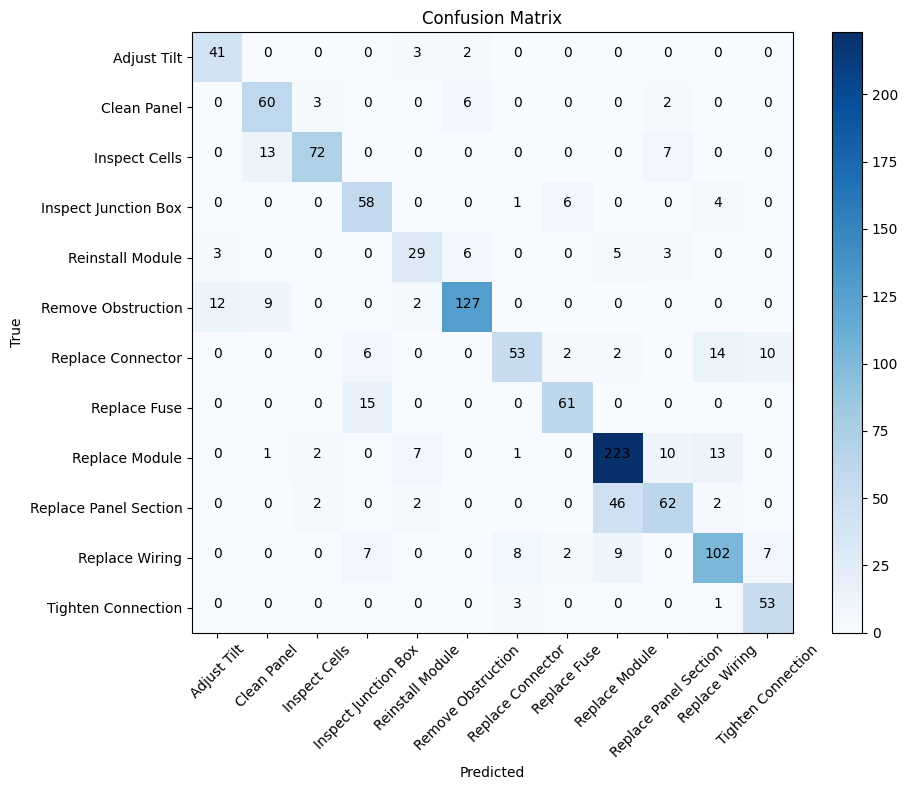

In [21]:
# Confusion Matrix

classes = best_model.classes_

cm = confusion_matrix(y_test,y_pred,labels=classes)

plt.figure(figsize=(10,8))
plt.imshow(cm,cmap="Blues")
plt.colorbar()

plt.xticks(range(len(classes)),classes,rotation=45)
plt.yticks(range(len(classes)),classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j,i,cm[i,j],ha="center")

plt.tight_layout()
plt.show()

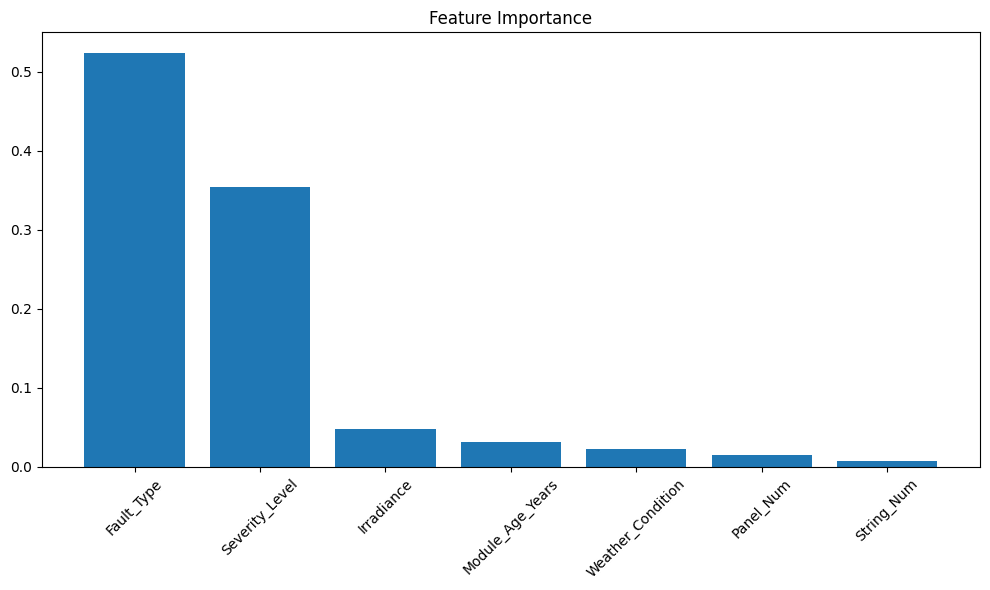

In [22]:
# Feature Importance

clf = best_model.named_steps["clf"]

importances = clf.feature_importances_

sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))

plt.bar(range(len(importances)),importances[sorted_idx])

plt.xticks(range(len(importances)),
           [ALL_FEATURES[i] for i in sorted_idx],
           rotation=45)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

#Save the model

In [23]:
joblib.dump(best_model, DRIVE_PATH + "rectification_dt_model.pkl")

print("Model saved to Google Drive")

Model saved to Google Drive


In [24]:
# Sample Prediction

sample = pd.DataFrame({
"Fault_Type":["Open Circuit"],
"Severity_Level":["High"],
"String_Num":[9],
"Panel_Num":[14],
"Weather_Condition":["Rainy"],
"Irradiance":[430],
"Module_Age_Years":[11]
})

prediction = best_model.predict(sample)

print("Recommended Rectification Action:")
print(prediction[0])

Recommended Rectification Action:
Inspect Junction Box
